# (노트) 인자분석 - FIFA 축구선수 능력치 
> 미완성

- toc:true
- branch: master
- badges: true
- comments: true
- author: 신록예찬
- categories: [응용통계]

### About this doc 

`-` 인자분석 예제: FIFA 축구선수 능력치 

`-` 데이터 출처: https://www.kaggle.com/bryanb/fifa-player-stats-database?select=FIFA21_official_data.csv

`-` 분석툴: `FactoMineR`

Lê, S., Josse, J., & Husson, F. (2008). FactoMineR: an R package for multivariate analysis. Journal of statistical software, 25(1), 1-18.

### Data

In [148]:
library(tidyverse)
data=read_csv("2021-07-01-FIFA21_official_data2.csv")


── Column specification ────────────────────────────────────────────────────────
cols(
  .default = col_double(),
  Name = col_character(),
  Photo = col_character(),
  Nationality = col_character(),
  Flag = col_character(),
  Club = col_character(),
  `Club Logo` = col_character(),
  Value = col_character(),
  Wage = col_character(),
  `Preferred Foot` = col_character(),
  `Work Rate` = col_character(),
  `Body Type` = col_character(),
  `Real Face` = col_character(),
  Position = col_character(),
  Joined = col_character(),
  `Loaned From` = col_character(),
  `Contract Valid Until` = col_character(),
  Height = col_character(),
  Weight = col_character(),
  `Best Position` = col_character(),
  `Release Clause` = col_character()
)
ℹ Use `spec()` for the full column specifications.




In [149]:
names(data)

[1] "ID"                       "Name"                    
 [3] "Age"                      "Photo"                   
 [5] "Nationality"              "Flag"                    
 [7] "Overall"                  "Potential"               
 [9] "Club"                     "Club Logo"               
[11] "Value"                    "Wage"                    
[13] "Special"                  "Preferred Foot"          
[15] "International Reputation" "Weak Foot"               
[17] "Skill Moves"              "Work Rate"               
[19] "Body Type"                "Real Face"               
[21] "Position"                 "Jersey Number"           
[23] "Joined"                   "Loaned From"             
[25] "Contract Valid Until"     "Height"                  
[27] "Weight"                   "Crossing"                
[29] "Finishing"                "HeadingAccuracy"         
[31] "ShortPassing"             "Volleys"                 
[33] "Dribbling"                "Curve"                   
[35] "FKAccuracy"               "LongPassing"             
[37] "BallControl"              "Acceleration"            
[39] "SprintSpeed"              "Agility"                 
[41] "Reactions"                "Balance"                 
[43] "ShotPower"                "Jumping"                 
[45] "Stamina"                  "Strength"                
[47] "LongShots"                "Aggression"              
[49] "Interceptions"            "Positioning"             
[51] "Vision"                   "Penalties"               
[53] "Composure"                "Marking"                 
[55] "StandingTackle"           "SlidingTackle"           
[57] "GKDiving"                 "GKHandling"              
[59] "GKKicking"                "GKPositioning"           
[61] "GKReflexes"               "Best Position"           
[63] "Best Overall Rating"      "Release Clause"          
[65] "DefensiveAwareness"

In [150]:
dat=data %>% 
filter(Nationality=='Korea Republic') %>% 
select('Name','Club','Best Position','Crossing',
       'Finishing','HeadingAccuracy','ShortPassing','Volleys',
       'Dribbling','Curve','FKAccuracy','LongPassing',
       'BallControl','Acceleration','SprintSpeed','Agility',
       'Reactions','Balance','ShotPower','Jumping',
       'Stamina','Strength','LongShots','Aggression',
       'Interceptions','Positioning','Vision','Penalties',
       'Composure','StandingTackle','SlidingTackle','GKDiving',
       'GKHandling','GKKicking','GKPositioning','GKReflexes') 

In [168]:
dat=dat[-9,]

In [169]:
X <- dat[,-c(1,2,3)]
#Y <- dat[,c(1,2,3)]

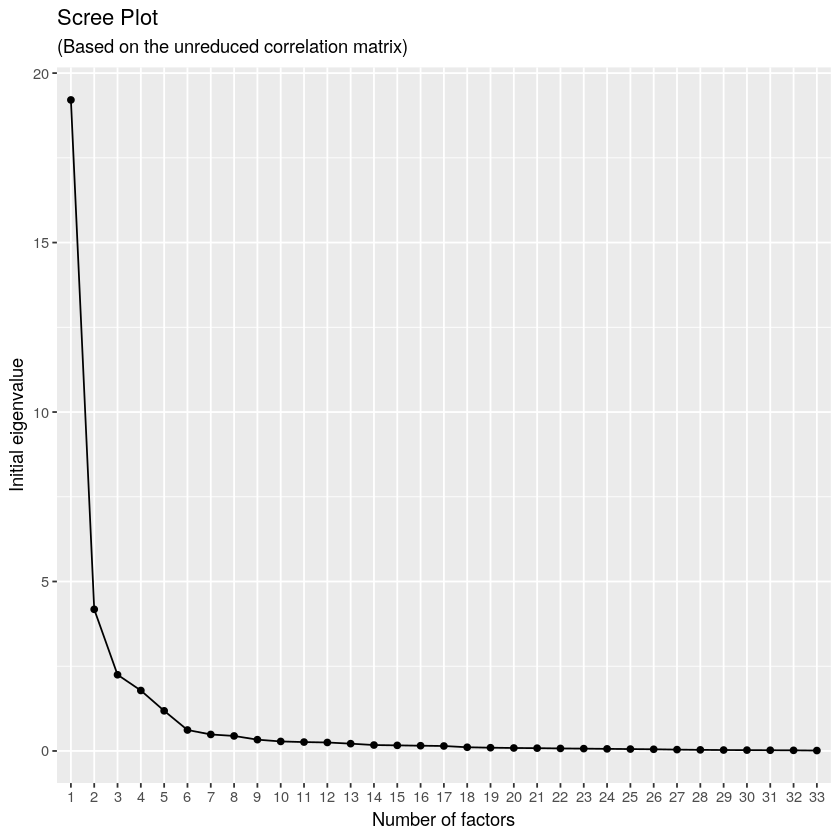

In [170]:
fafitfree <- fa(X,nfactors = ncol(X), rotate = "none")
n_factors <- length(fafitfree$e.values)
scree     <- data.frame(
  Factor_n =  as.factor(1:n_factors), 
  Eigenvalue = fafitfree$e.values)
ggplot(scree, aes(x = Factor_n, y = Eigenvalue, group = 1)) + 
  geom_point() + geom_line() +
  xlab("Number of factors") +
  ylab("Initial eigenvalue") +
  labs( title = "Scree Plot", 
        subtitle = "(Based on the unreduced correlation matrix)")

Parallel analysis suggests that the number of factors =  4  and the number of components =  4 


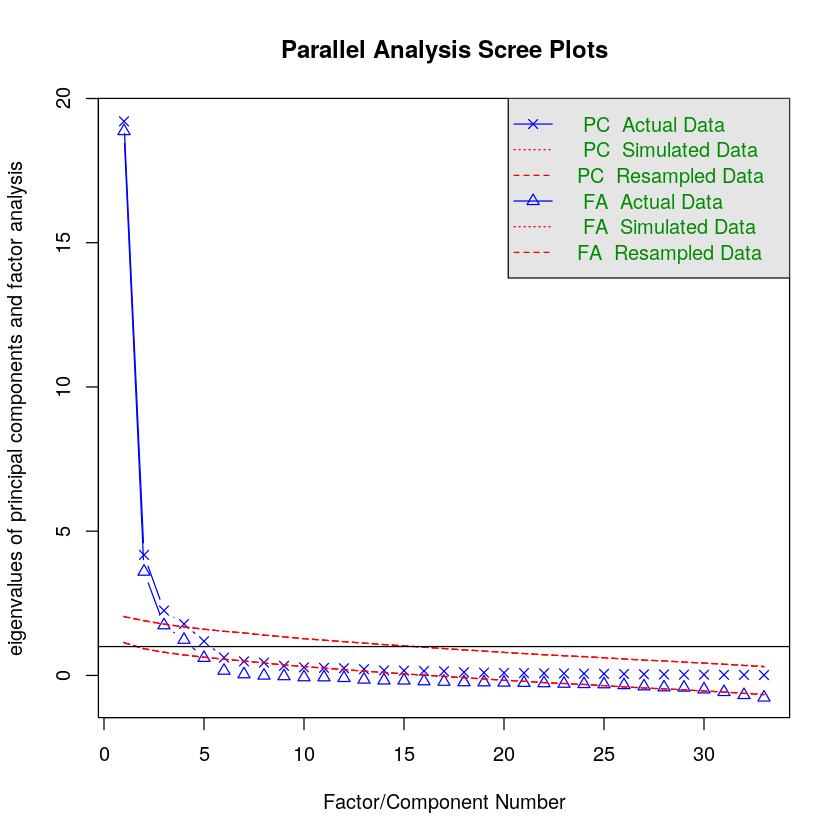

In [171]:
parallel <- fa.parallel(X)

In [175]:
fa.none <- fa(r=X, nfactors = 5, 
 # covar = FALSE, SMC = TRUE,
 fm='pa', # type of factor analysis we want to use (“pa” is principal axis factoring)
 max.iter=100, # (50 is the default, but we have changed it to 100
 rotate='varimax') # none rotation
print(fa.none)

Factor Analysis using method =  pa
Call: fa(r = X, nfactors = 5, rotate = "varimax", max.iter = 100, fm = "pa")
Standardized loadings (pattern matrix) based upon correlation matrix
                  PA1   PA3   PA2   PA5   PA4   h2    u2 com
Crossing         0.69  0.35  0.26  0.39  0.00 0.82 0.178 2.5
Finishing        0.77  0.39 -0.22  0.28  0.14 0.90 0.101 2.1
HeadingAccuracy  0.33  0.51  0.25  0.10  0.69 0.91 0.087 2.7
ShortPassing     0.71  0.38  0.37  0.28  0.14 0.88 0.119 2.6
Volleys          0.80  0.38 -0.17  0.18  0.18 0.88 0.125 1.8
Dribbling        0.71  0.47  0.14  0.42  0.03 0.93 0.065 2.6
Curve            0.83  0.34  0.13  0.16 -0.01 0.84 0.156 1.5
FKAccuracy       0.80  0.27  0.23  0.07  0.01 0.78 0.223 1.4
LongPassing      0.70  0.24  0.50  0.17  0.02 0.83 0.166 2.2
BallControl      0.71  0.50  0.23  0.33  0.18 0.95 0.055 2.7
Acceleration     0.31  0.31  0.15  0.86  0.05 0.96 0.043 1.6
SprintSpeed      0.29  0.36  0.11  0.78  0.10 0.83 0.165 1.8
Agility          0.50  0.3

In [176]:
factanal.none <- factanal(X, factors=4, scores = c("regression"), rotation = "varimax")
print(factanal.none)


Call:
factanal(x = X, factors = 4, scores = c("regression"), rotation = "varimax")

Uniquenesses:
       Crossing       Finishing HeadingAccuracy    ShortPassing         Volleys 
          0.188           0.121           0.334           0.126           0.154 
      Dribbling           Curve      FKAccuracy     LongPassing     BallControl 
          0.072           0.201           0.254           0.203           0.051 
   Acceleration     SprintSpeed         Agility       Reactions         Balance 
          0.040           0.141           0.240           0.426           0.369 
      ShotPower         Jumping         Stamina        Strength       LongShots 
          0.238           0.825           0.260           0.689           0.097 
     Aggression   Interceptions     Positioning          Vision       Penalties 
          0.358           0.100           0.091           0.223           0.183 
      Composure  StandingTackle   SlidingTackle        GKDiving      GKHandling 
          

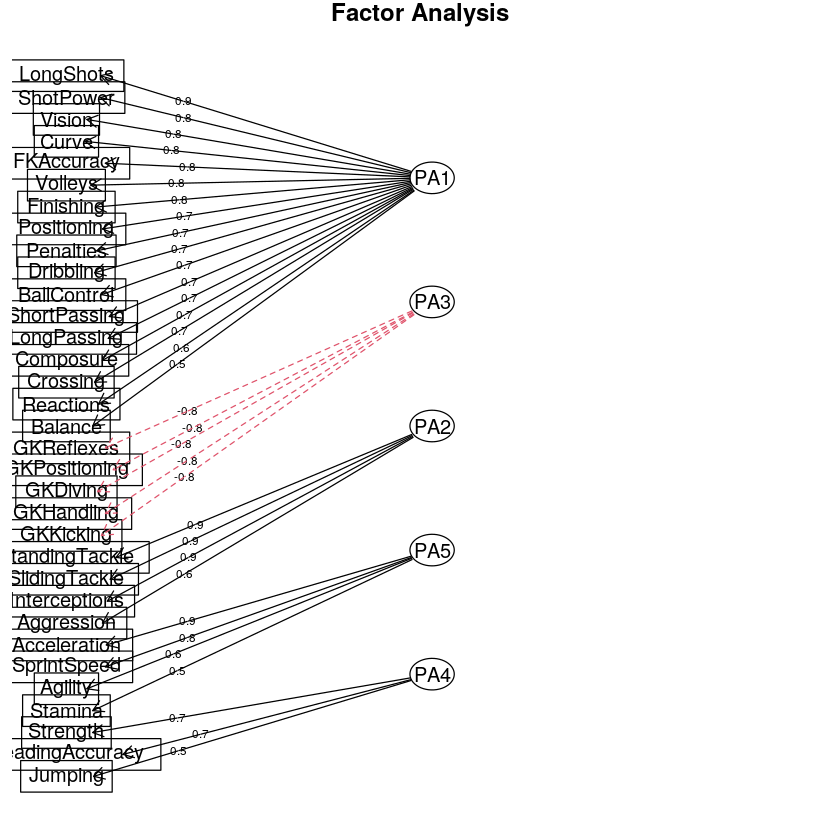

In [177]:
fa.diagram(fa.none)